# Makemore Part 1 — Bigram Language Model

This notebook builds a **bigram character-level language model** that learns to generate human-like names by studying patterns in a large list of real names.

The models are implemented in **two ways**:

| Approach           | Method                        | Key idea                                                 |
| ------------------ | ----------------------------- | -------------------------------------------------------- |
| **Statistical**    | Count matrix + smoothing      | Directly count how often each pair of characters appears |
| **Neural Network** | Single linear layer + softmax | Learn the same distribution via gradient descent         |

Both approaches ultimately optimise the same objective, that is, **minimising the average negative log-likelihood** of the training data and produce equivalent results.


## 1 Imports


In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
import mlflow, os, torch

# ── MLflow setup ──────────────────────────────────────────────────────────────
# Ensure we're in J:/AML-3103 (where names.txt lives) regardless of how the
# kernel was launched (interactive vs. nbconvert from the refactored/ subdir)
if not os.path.exists('names.txt') and os.path.exists('../names.txt'):
    os.chdir('..')

os.makedirs('checkpoints', exist_ok=True)
mlflow.set_experiment('makemore')
_mlflow_run = mlflow.start_run(run_name='part1-bigrams')
print(f'MLflow run started  id={_mlflow_run.info.run_id}')

MLflow run started  id=cda7cd04d7c645589e6d6cea2e21c499


## 2 Load and Explore the Dataset

`names.txt` contains one name per line (e.g. _emma_, _olivia_, …).  
Store every line into a Python list so that each element is a single lowercase name string.


In [3]:
words = open('names.txt', 'r').read().splitlines()
print(f'First 10    : {words[:10]}\n')

First 10    : ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']



In [4]:
print(f'Total words : {len(words)}')
print(f'Shortest    : {min(len(w) for w in words)} characters')
print(f'Longest     : {max(len(w) for w in words)} characters')

Total words : 32033
Shortest    : 2 characters
Longest     : 15 characters


## 3 Build the Vocabulary and Character Mappings

To build up the vocabulary set each character needs an integer index so we can store counts in a matrix.

- `char_mapping` (string → int): maps each character to its row/column index.
- `char_decode` (int → string): the reverse lookup used when decoding predictions.
- The special token `.` (index **0**) serves as both a start-of-word and end-of-word marker, so the model learns how names begin and end. Instead having seperate special tokens for which may introduce rows or columns with no meaningful occurances or value, `.` was selected


In [5]:
# all unique characters in the dataset, basically the entire english alphabet
# join all words into one string, extract unique characters via set, sort them alphabetically into a list
chars = sorted(list(set(''.join(words))))
# 'a'->1, 'b'->2, ..., 'z'->26
# build a dict mapping each character to a unique integer starting at 1, reserving 0 for the special token
char_mapping = {s: i + 1 for i, s in enumerate(chars)}
# manually assign index 0 to '.' so it sits at the top-left corner of the bigram matrix as the start/end token
char_mapping['.'] = 0
# build the reverse mapping from integer back to character, used when decoding predictions during sampling
char_decode = {i: s for s, i in char_mapping.items()}

vocab_size = len(char_mapping)
print(f'Vocabulary size: {vocab_size}')
print(f'Sample mapping : {list(char_mapping.items())[:5]}')

Vocabulary size: 27
Sample mapping : [('a', 1), ('b', 2), ('c', 3), ('d', 4), ('e', 5)]


## 4 Build the Bigram Count Matrix

We iterate over every consecutive pair of characters in each word (including the boundary `.` tokens) and tally the counts in a **27 × 27** integer matrix `N`.

`N[i, j]` = number of times character `i` was immediately followed by character `j` in the training set.


In [6]:
# Initialize a 27x27 matrix of zeros to hold bigram counts, dtype=torch.int32 since we're counting occurrences
N = torch.zeros((vocab_size, vocab_size), dtype=torch.int32)

# Iterate over every word in the dataset
for w in words:
    # Wrap word with '.' boundary tokens so the model learns how names start and end
    chs = ['.'] + list(w) + ['.']      # wrap word with boundary tokens
    # Slide a window of size 2 over the character list to get consecutive pairs
    for ch1, ch2 in zip(chs, chs[1:]):
        # Convert current character to its integer index — this is the row
        ix1 = char_mapping[ch1]
        # Convert next character to its integer index — this is the column
        ix2 = char_mapping[ch2]
        # Increment the count for this bigram pair in the matrix
        N[ix1, ix2] += 1

# Confirm the matrix is 27x27 as expected
print('Bigram count matrix shape:', N.shape)
print('Most common bigrams (top 5):')
# Flatten the 27x27 matrix into a list of (bigram_string, count) tuples by looping over all i,j pairs
flat_counts = [(char_decode[i] + char_decode[j], N[i, j].item())
               for i in range(vocab_size) for j in range(vocab_size)]
# Sort by count descending and print the top 5 most frequent bigrams
for bigram, count in sorted(flat_counts, key=lambda x: -x[1])[:5]:
    print(f'  {bigram!r:6s}  {count}')

Bigram count matrix shape: torch.Size([27, 27])
Most common bigrams (top 5):
  'n.'    6763
  'a.'    6640
  'an'    5438
  '.a'    4410
  'e.'    3983


## 5 Visualise the Bigram Count Matrix

A heatmap makes the count matrix easy to interpret visually.

- **Rows** = the _current_ character (context)
- **Columns** = the _next_ character (prediction)
- Darker blue cells indicate more frequent bigrams.


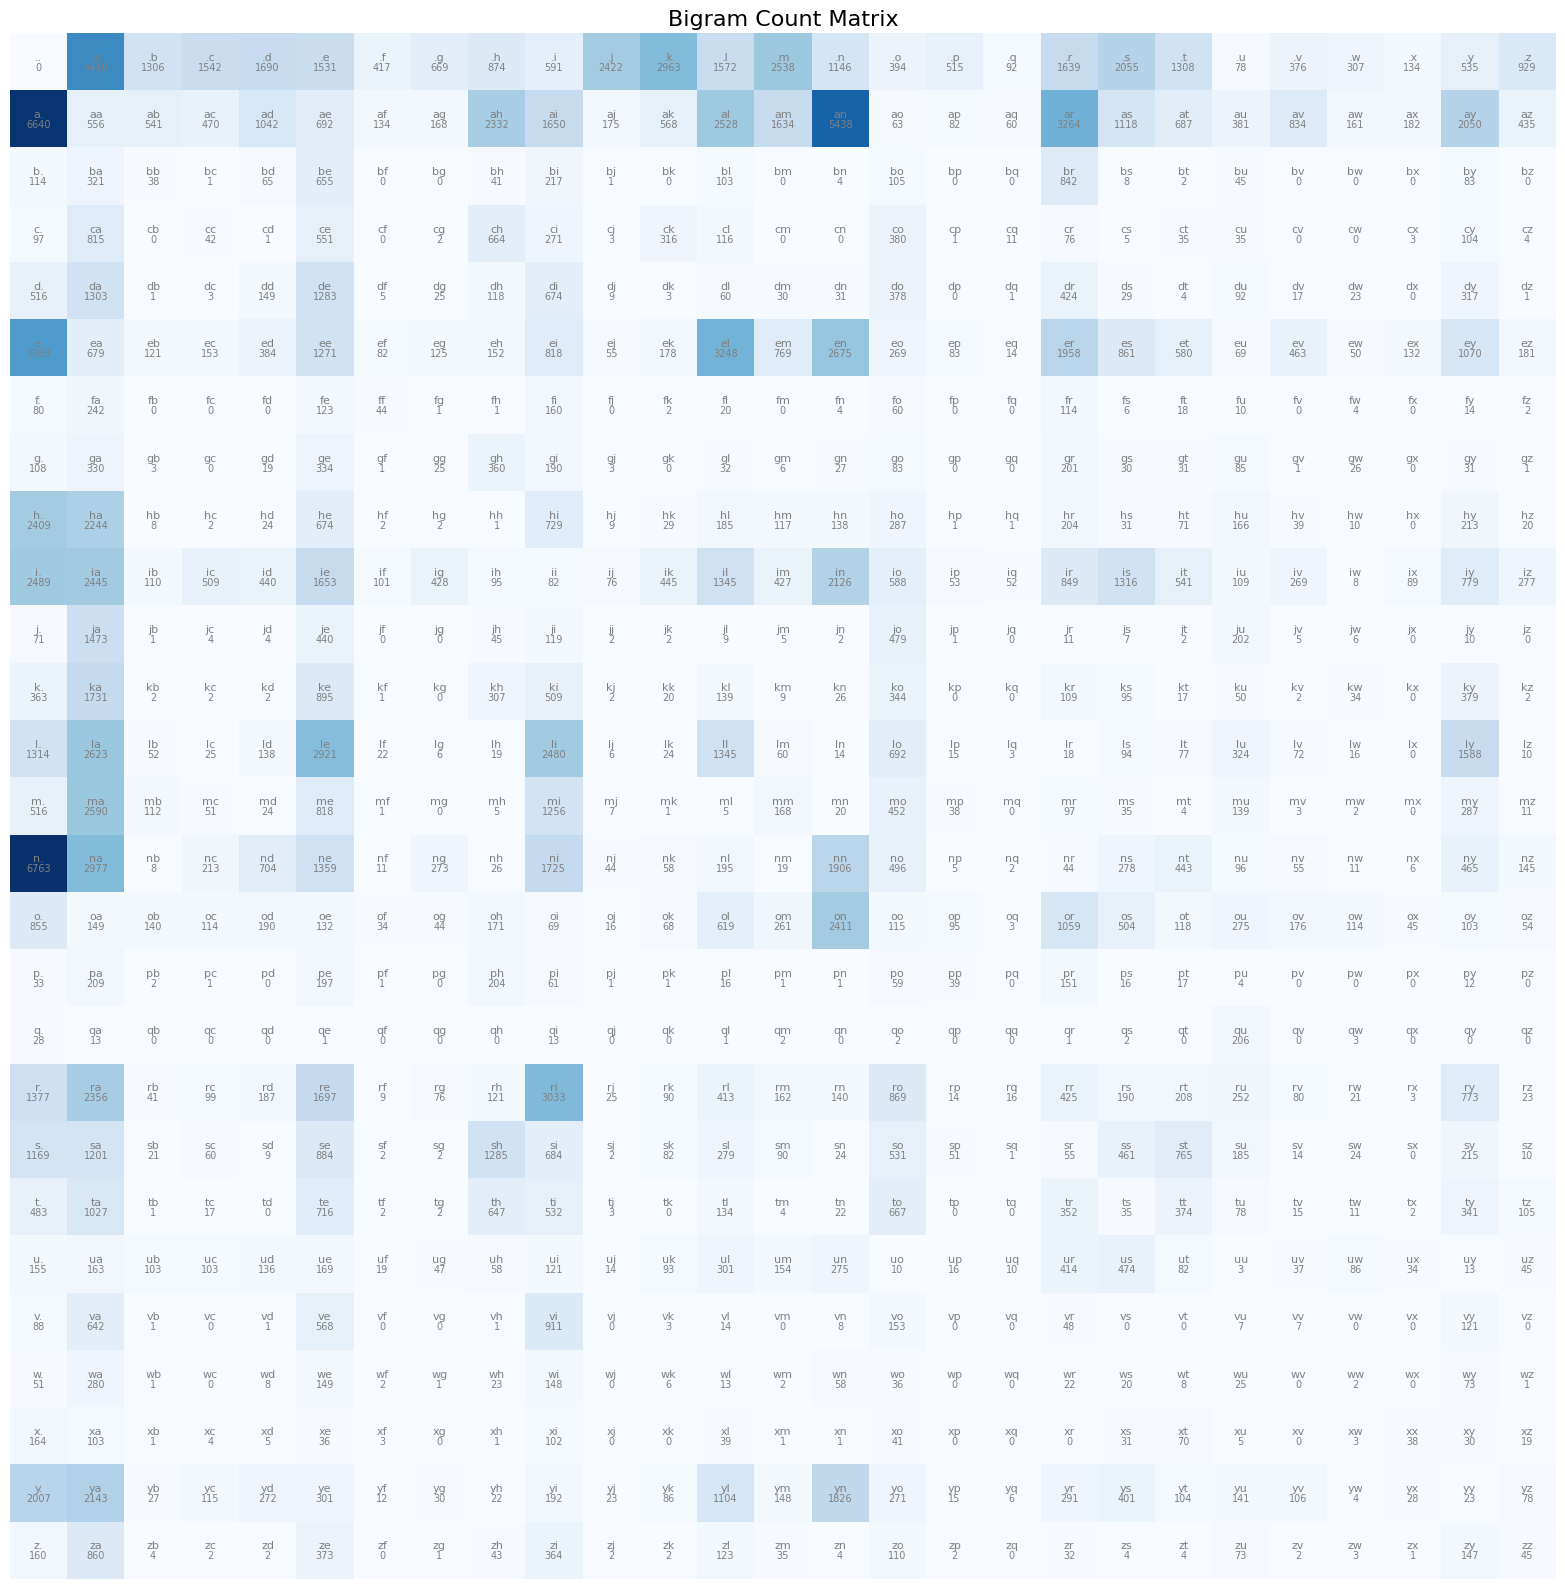

In [7]:
# Create a 16x16 inch figure to give enough space for all 27x27 cells to be readable
plt.figure(figsize=(16, 16))
# Render the bigram count matrix N as a heatmap — darker blue cells mean higher bigram counts
plt.imshow(N, cmap='Blues')
# Loop over every cell in the 27x27 matrix to annotate it with text
for i in range(vocab_size):
    for j in range(vocab_size):
        # Concatenate the row character and column character to form the bigram label e.g. 'ab'
        chstr = char_decode[i] + char_decode[j]
        # Print the bigram label in the top half of the cell
        plt.text(j, i, chstr,   ha='center',
                 va='bottom', color='gray', fontsize=8)
        # Print the raw count in the bottom half of the cell — .item() converts the tensor scalar to a Python int
        plt.text(j, i, N[i, j].item(), ha='center',
                 va='top',    color='gray', fontsize=7)
# Add a title to the plot
plt.title('Bigram Count Matrix', fontsize=16)
# Hide the axis ticks and labels since the cell annotations already convey all the information
plt.axis('off')
# Trim whitespace around the figure
plt.tight_layout()

## 6 Statistical Model: Probability Matrix with Laplace Smoothing

To turn raw counts into probabilities we:

1. **Add 1 to every count** (Laplace / add-one smoothing) — this avoids zero probabilities for unseen bigrams, which would blow up the log-likelihood to −∞.
2. **Normalise each row** so all 27 values sum to 1, giving `P[i]` the probability distribution over the next character given character `i`.


In [8]:
# Add 1 to every cell in N (Laplace smoothing) to avoid zero probabilities that would cause log(0) = -inf, then convert to float for division
P = (N + 1).float()
# Normalize each row into a probability distribution — sum(dim=1) collapses each row to a single total, keepdim=True keeps shape (27,1) for correct broadcasting across all 27 columns
P /= P.sum(dim=1, keepdim=True)
# Print the probability distribution for the start token '.' — shows how likely each character is to appear as the first letter of a name
print(P[0])
# Verify that row 0 sums to exactly 1.0 — confirming the normalization worked correctly
print(f'Row sum check: {P[0].sum().item():.4f}')

tensor([3.1192e-05, 1.3759e-01, 4.0767e-02, 4.8129e-02, 5.2745e-02, 4.7785e-02,
        1.3038e-02, 2.0898e-02, 2.7293e-02, 1.8465e-02, 7.5577e-02, 9.2452e-02,
        4.9064e-02, 7.9195e-02, 3.5777e-02, 1.2321e-02, 1.6095e-02, 2.9008e-03,
        5.1154e-02, 6.4130e-02, 4.0830e-02, 2.4641e-03, 1.1759e-02, 9.6070e-03,
        4.2109e-03, 1.6719e-02, 2.9008e-02])
Row sum check: 1.0000


## 7 Sample Names from the Statistical Model

To generate a name we do **autoregressive sampling**:

1. Start with the boundary token `.` (index 0).
2. Look up the probability distribution for the current character: `P[ix]`.
3. Sample the next character index using `torch.multinomial`.
4. Append the corresponding character to the output.
5. Repeat until the `.` end token is sampled.


In [9]:
# Fixed seed for reproducibility — same seed always produces the same sequence of sampled names
g = torch.Generator().manual_seed(2147483647)

print('Names sampled from the statistical bigram model:')
# Generate 10 sample names
for _ in range(10):
    # List to collect characters of the current name
    out = []
    # Start at index 0, the '.' start token
    ix = 0
    while True:
        # Look up the probability distribution for the current character from row ix of P
        p = P[ix]
        # Sample the next character index from the distribution — higher probability characters get picked more often
        ix = torch.multinomial(
            p, num_samples=1, replacement=True, generator=g).item()
        # Convert sampled index back to its character and append to output
        out.append(char_decode[ix])
        if ix == 0:
            break
    # Join all characters into a string, stripping the trailing '.' end token before printing
    print(''.join(out[:-1]))

Names sampled from the statistical bigram model:
cexze
momasurailezitynn
konimittain
llayn
ka
da
staiyaubrtthrigotai
moliellavo
ke
teda


## 8 Evaluating the Statistical Model: Negative Log-Likelihood

We need a scalar **loss** to measure model quality. We use the **average negative log-likelihood (NLL)**:

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N} \log P(c_{i+1} \mid c_i)$$

- A **lower** NLL means the model assigns higher probability to the actual next characters → it has learned the data better.
- Taking the log converts the product of probabilities into a sum (numerically stable).
- Negating flips the sign so we _minimise_ rather than maximise.


In [10]:
# Running total of log probabilities across all bigrams in the dataset
log_likelihood = 0.0
# Counter for total number of bigrams seen
n = 0

# Iterate over every word in the dataset
for w in words:
    # Wrap word with '.' start and end tokens
    chs = ['.'] + list(w) + ['.']
    # Slide a window of size 2 to get consecutive character pairs
    for ch1, ch2 in zip(chs, chs[1:]):
        # Convert current character to its integer index
        ix1 = char_mapping[ch1]
        # Convert next character to its integer index
        ix2 = char_mapping[ch2]
        # Look up the probability of this bigram, take its log and accumulate — .item() converts tensor scalar to a Python float
        log_likelihood += torch.log(P[ix1, ix2]).item()
        n += 1

# Negate to get NLL — we minimize this, lower means the model assigns higher probability to the training data
nll = -log_likelihood
# Divide by total bigram count to get a per-bigram average, normalizing across dataset size
avg_nll = nll / n

# More negative means the model is more confident and correct across the dataset
print(f'Total log-likelihood : {log_likelihood:.2f}')
print(f'Total NLL            : {nll:.2f}')
# This is the key metric — directly comparable across models and dataset sizes
print(f'Average NLL (loss)   : {avg_nll:.4f}')

Total log-likelihood : -560001.88
Total NLL            : 560001.88
Average NLL (loss)   : 2.4546


## 9 Neural Network Approach: Dataset Preparation

We now replicate the statistical model using a **single linear layer** trained with gradient descent. The key insight is:

> The rows of the weight matrix `W` after training should converge to (log) values proportional to the rows of the count matrix `N`.

**Dataset format:**

- `xs` — integer tensor of _input_ character indices (one per bigram)
- `ys` — integer tensor of _target_ character indices (the next character for each input)

We extract bigrams from the **full** dataset, so both tensors have one entry per consecutive character pair across all words.


In [11]:
# Initialize empty lists to hold input and label integer indices
xs, ys = [], []
# Iterate over every word in the full dataset
for w in words:
    # Wrap word with '.' start and end tokens
    chs = ['.'] + list(w) + ['.']
    # Slide a window of size 2 to get consecutive character pairs
    for ch1, ch2 in zip(chs, chs[1:]):
        # Append the input character index to xs
        xs.append(char_mapping[ch1])
        # Append the label character index to ys
        ys.append(char_mapping[ch2])

# Convert to PyTorch tensors — each element is one bigram's input character index
xs = torch.tensor(xs)   # shape: (num_bigrams,)
# Convert to PyTorch tensors — each element is the corresponding target character index
ys = torch.tensor(ys)   # shape: (num_bigrams,)

# Count total bigrams using nelement() which returns the total number of elements in the tensor
num = xs.nelement()
print(f'Total training bigrams: {num}')
# Print first 5 input indices alongside their decoded characters to sanity check the mapping
print(
    f'xs[:5] = {xs[:5].tolist()}  →  {[char_decode[i] for i in xs[:5].tolist()]}')
# Print first 5 label indices alongside their decoded characters to verify xs and ys are correctly aligned
print(
    f'ys[:5] = {ys[:5].tolist()}  →  {[char_decode[i] for i in ys[:5].tolist()]}')

Total training bigrams: 228146
xs[:5] = [0, 5, 13, 13, 1]  →  ['.', 'e', 'm', 'm', 'a']
ys[:5] = [5, 13, 13, 1, 0]  →  ['e', 'm', 'm', 'a', '.']


## 10 One-Hot Encoding

The neural network expects a **continuous vector** as input, not an integer index.  
We convert each integer index to a **one-hot vector** of length 27:  
all zeros except a single `1` at position `i`.

After encoding, `xenc` has shape `(num_bigrams, 27)` — one row per training example.


One-hot encoded input shape: torch.Size([228146, 27])
First example (input char index 0 = "."):


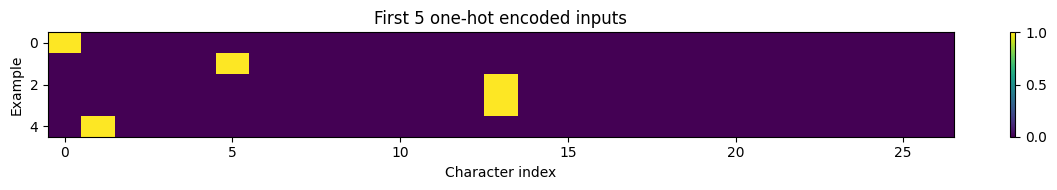

In [12]:
xenc = F.one_hot(xs, num_classes=vocab_size).float()   # (num_bigrams, 27)

print('One-hot encoded input shape:', xenc.shape)
print('First example (input char index 0 = "."):')
plt.figure(figsize=(12, 2))
plt.imshow(xenc[:5], aspect='auto')
plt.xlabel('Character index')
plt.ylabel('Example')
plt.title('First 5 one-hot encoded inputs')
plt.colorbar()
plt.tight_layout()

## 11 Initialise the Neural Network

Our model is a **single linear layer** — just one weight matrix `W` of shape `(27, 27)`.  
There is no bias and no activation function before the softmax.

- The matrix multiplication `xenc @ W` produces **logits** — unnormalised log-counts.
- `W` is initialised with random normal values and tagged with `requires_grad=True` so PyTorch can compute gradients during backprop.

Conceptually this is equivalent to learning `log N[i]` (up to normalisation) for each row `i`.


In [13]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((vocab_size, vocab_size), generator=g, requires_grad=True)

print('Weight matrix shape:', W.shape)
print('(Each of the 27 rows is the learned log-count distribution for one input character.)')

Weight matrix shape: torch.Size([27, 27])
(Each of the 27 rows is the learned log-count distribution for one input character.)


## 12 Training Loop — Forward Pass, Backward Pass, and Weight Update

Each iteration of gradient descent performs three steps:

1. **Forward pass** — compute the loss:
   - `logits = xenc @ W` — dot product gives one logit vector per example
   - `counts = logits.exp()` — exponentiate to get positive "pseudo-counts"
   - `probs = counts / counts.sum(dim=1, keepdim=True)` — normalise → softmax probabilities
   - `loss` = mean NLL of the correct next characters + L2 regularisation on `W`

2. **Backward pass** — `loss.backward()` computes ∂loss/∂W automatically.

3. **Parameter update** — gradient descent: `W ← W - lr × ∂loss/∂W`.

> **L2 regularisation** (`0.01 * (W**2).mean()`) penalises large weights, acting as a smoothing prior that prevents the model from becoming overconfident on rare bigrams.


Step    0 | Loss: 3.7686

Step   20 | Loss: 2.5823


Step   40 | Loss: 2.5213


Step   60 | Loss: 2.5027


Step   80 | Loss: 2.4944


...

Step  120 | Loss: 2.4873


Step  140 | Loss: 2.4856


Step  160 | Loss: 2.4844


Step  180 | Loss: 2.4836


Step  199 | Loss: 2.4830


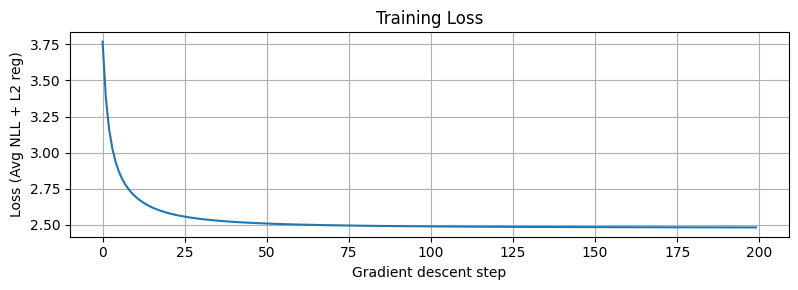

In [14]:
g = torch.Generator().manual_seed(2147483647)
# Initialize 27x27 weight matrix with random normal values, requires_grad=True tells PyTorch to track operations on W for backpropagation
W = torch.randn((vocab_size, vocab_size), generator=g, requires_grad=True)

# Step size controlling how much we adjust W each iteration — large value (50) works here because the problem is simple
learning_rate = 50
# Number of gradient descent iterations to run
num_steps = 200
# L2 regularisation coefficient — scales the penalty on large weights to prevent overfitting
reg_strength = 0.01     # L2 regularisation coefficient

# List to track loss at each step for plotting the training curve
losses = []
for step in range(num_steps):

    # ── Forward pass ──────────────────────────────────────────────────
    # Convert all input indices to one-hot vectors of length 27, cast to float for matrix multiplication
    xenc = F.one_hot(xs, num_classes=vocab_size).float()  
    # Matrix multiply inputs by W to get logits — interpreted as log-counts since we exponentiate next
    # (N, 27) — log-counts
    logits = xenc @ W
    # Exponentiate logits to get positive pseudo-counts analogous to the bigram count matrix N
    counts = logits.exp()                                
    # Normalize each row into a probability distribution over 27 characters — this is the softmax operation
    # (N, 27) — softmax probs
    probs = counts / counts.sum(dim=1, keepdim=True)

    # probs[torch.arange(num), ys] indexes each row to grab the probability of the correct next character,
    # .log().mean() computes average NLL, reg_strength * (W**2).mean() is L2 regularisation penalising large weights
    loss = -probs[torch.arange(num), ys].log().mean() + \
        reg_strength * (W ** 2).mean()
    # Store the scalar loss value for plotting later
    losses.append(loss.item())

    # ── Backward pass ─────────────────────────────────────────────────
    # Reset gradients to None before backward pass to prevent accumulation from previous iterations
    # reset gradients (equivalent to optimizer.zero_grad())
    W.grad = None
    # Compute gradients of loss with respect to W via backpropagation
    loss.backward()

    # ── Weight update (gradient descent) ──────────────────────────────
    # Nudge W in the opposite direction of the gradient scaled by learning rate — .data skips gradient tracking on this operation
    W.data -= learning_rate * W.grad

    # Print loss every 20 steps and at the final step to monitor training progress
    if step % 20 == 0 or step == num_steps - 1:
        print(f'Step {step:4d} | Loss: {loss.item():.4f}')

# Plot training curve
# Create a wide, short figure to display the loss curve
plt.figure(figsize=(8, 3))
# Plot loss values across all training steps — should trend downward as the model improves
plt.plot(losses)
plt.xlabel('Gradient descent step')
plt.ylabel('Loss (Avg NLL + L2 reg)')
plt.title('Training Loss')
# Add grid lines for easier reading of the loss values
plt.grid(True)
plt.tight_layout()

## 13 Sample Names from the Neural Network Model

Sampling from the neural network follows the same autoregressive procedure as before, but instead of looking up a row in the pre-computed probability matrix `P`, we:

1. One-hot encode the current character index.
2. Do a forward pass through `W` to get logits.
3. Apply softmax to obtain probabilities.
4. Sample the next character index from that distribution.

Because the neural net has been trained to minimise the same NLL objective, the generated names should look similar to those from the statistical model.


In [15]:
# Fixed seed for reproducibility — ensures same names are generated every run
g = torch.Generator().manual_seed(2147483647)

print('Names sampled from the trained neural network:')
# Generate 10 sample names
for _ in range(10):
    # List to collect characters of the current name
    out = []
    # Start at index 0, the '.' start token
    ix = 0
    while True:
        # One forward pass for a single character
        # Encode the current character index as a one-hot vector of shape (1, 27)
        xenc = F.one_hot(torch.tensor(
            [ix]), num_classes=vocab_size).float()  # (1, 27)
        # Matrix multiply by W to get logits for the next character
        logits = xenc @ W                           # (1, 27)
        # Exponentiate logits to get positive pseudo-counts
        counts = logits.exp()
        # Normalize into a probability distribution over 27 characters — softmax
        p = counts / counts.sum(dim=1, keepdim=True)

        # Sample the next character index from the probability distribution
        ix = torch.multinomial(
            p, num_samples=1, replacement=True, generator=g).item()
        # Convert sampled index back to its character and append to output
        out.append(char_decode[ix])
        if ix == 0:   # end token → word complete
            break
    # Join all characters into a string, stripping the trailing '.' before printing
    print(''.join(out[:-1]))

Names sampled from the trained neural network:
cexze
momasurailezityha
konimittain
llayn
ka
da
staiyaubrtthrigotai
moliellavo
ke
teda


## 14 Comparison: Statistical vs. Neural Network Model

Both approaches compute the same kind of probability distribution over the next character.  
Here we verify that their average NLLs are close — confirming the neural network has converged to approximately the same solution as the statistical model.


In [16]:
# Statistical model NLL
# Running total of log probabilities for the statistical model
log_lik_stat = 0.0
# Counter for total number of bigrams
n_stat = 0
# Iterate over every word to compute log likelihood under the statistical model
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        # Look up P[i,j] directly using char_mapping, take its log and accumulate — .item() converts tensor scalar to Python float
        log_lik_stat += torch.log(P[char_mapping[ch1],
                                  char_mapping[ch2]]).item()
        n_stat += 1
# Negate and normalize by total bigram count to get average NLL for the statistical model
nll_stat = -log_lik_stat / n_stat

# Neural network model NLL
# torch.no_grad() disables gradient tracking since we're only doing inference, saving memory and computation
with torch.no_grad():
    # One-hot encode all input indices at once for a single batched forward pass
    xenc_all = F.one_hot(xs, num_classes=vocab_size).float()
    # Matrix multiply by W to get logits for all bigrams simultaneously
    logits = xenc_all @ W
    # Exponentiate to get pseudo-counts
    counts = logits.exp()
    # Normalize each row into a probability distribution — softmax
    probs = counts / counts.sum(dim=1, keepdim=True)
    # Index each row by its correct label ys, take log, average, and negate to get average NLL
    nll_nn = -probs[torch.arange(num), ys].log().mean().item()

# Print both NLLs side by side — they should be very close if the neural network has converged
print(f'Statistical model  — Average NLL: {nll_stat:.4f}')
print(f'Neural network     — Average NLL: {nll_nn:.4f}')
print()
# Both models optimize the same objective so they converge to the same solution
print('The two values converge because the neural network learns the same')
print('log-count statistics that the count matrix captures directly.')

Statistical model  — Average NLL: 2.4546
Neural network     — Average NLL: 2.4653

The two values converge because the neural network learns the same
log-count statistics that the count matrix captures directly.


In [17]:
# ── MLflow: log params, metrics, and model checkpoint ────────────────────────
mlflow.log_params({
    'vocab_size':    vocab_size,
    'num_steps':     num_steps,
    'learning_rate': learning_rate,
    'reg_strength':  reg_strength,
})
mlflow.log_metric('statistical_avg_nll', nll_stat)
mlflow.log_metric('neural_avg_nll',      nll_nn)

ckpt_path = 'checkpoints/part1_bigram.pt'
torch.save({
    'W':             W.data,
    'P':             P,
    'stoi':          char_mapping,
    'itos':          char_decode,
    'vocab_size':    vocab_size,
    'num_steps':     num_steps,
    'learning_rate': learning_rate,
    'reg_strength':  reg_strength,
}, ckpt_path)
mlflow.log_artifact(ckpt_path)
mlflow.end_run()
print(f'MLflow run complete  stat_nll={nll_stat:.4f}  nn_nll={nll_nn:.4f}  ckpt={ckpt_path}')

MLflow run complete  stat_nll=2.4546  nn_nll=2.4653  ckpt=checkpoints/part1_bigram.pt
